In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, classification_report, roc_auc_score

: 

In [ ]:
data = pd.read_csv('/content/Social_Network_Ads.csv')
print(data.head())

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0


In [ ]:
# Encode categorical variables
label_encoder = LabelEncoder()
data['Gender'] = label_encoder.fit_transform(data['Gender'])  # Male: 1, Female: 0

In [ ]:
X = data[['Gender', 'Age', 'EstimatedSalary']]
y = data['Purchased']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

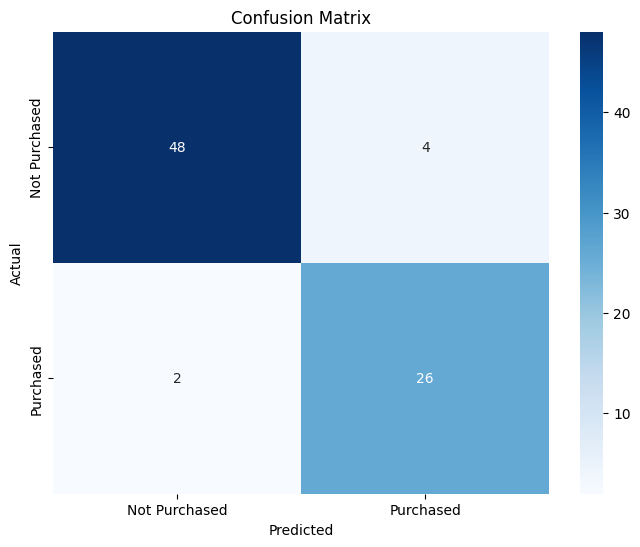

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# After making predictions
conf_matrix = confusion_matrix(y_test, model.predict(X_test))

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Purchased', 'Purchased'], yticklabels=['Not Purchased', 'Purchased'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

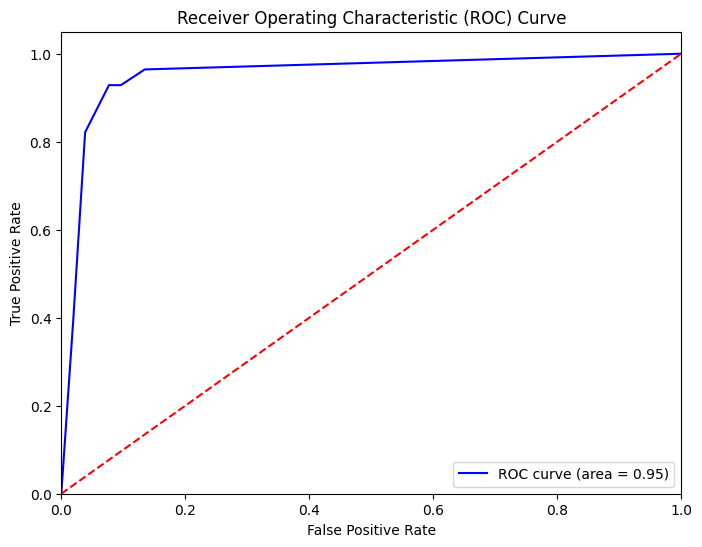

In [ ]:
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)

# Plotting the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

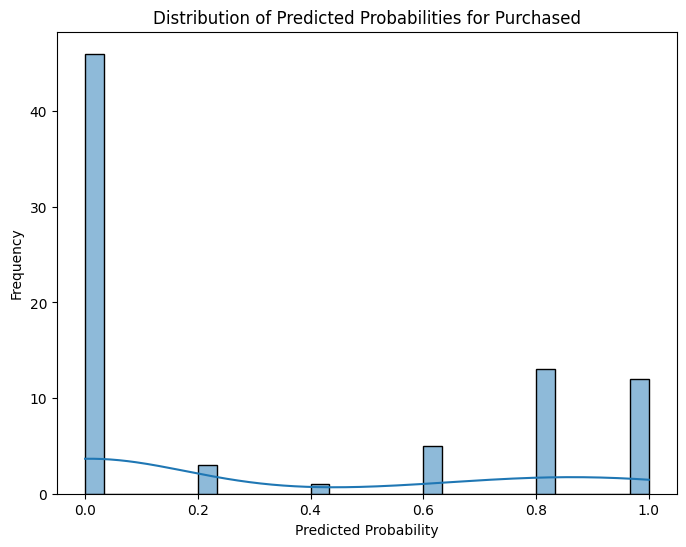

In [ ]:
# Get predicted probabilities
predicted_probabilities = model.predict_proba(X_test)[:, 1]

# Plotting the distribution of predicted probabilities
plt.figure(figsize=(8, 6))
sns.histplot(predicted_probabilities, bins=30, kde=True)
plt.title('Distribution of Predicted Probabilities for Purchased')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.show()

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Support Vector Machine': SVC(probability=True),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

In [ ]:
for model_name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

    # Print evaluation metrics
    print(f"Model: {model_name}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Confusion Matrix:\n{conf_matrix}")
    print(f"Classification Report:\n{class_report}")
    print(f"AUC ROC: {roc_auc:.4f}\n")

Model: Logistic Regression
Accuracy: 0.8875
F1 Score: 0.8235
Confusion Matrix:
[[50  2]
 [ 7 21]]
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92        52
           1       0.91      0.75      0.82        28

    accuracy                           0.89        80
   macro avg       0.90      0.86      0.87        80
weighted avg       0.89      0.89      0.88        80

AUC ROC: 0.9705

Model: Decision Tree
Accuracy: 0.8500
F1 Score: 0.7857
Confusion Matrix:
[[46  6]
 [ 6 22]]
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        52
           1       0.79      0.79      0.79        28

    accuracy                           0.85        80
   macro avg       0.84      0.84      0.84        80
weighted avg       0.85      0.85      0.85        80

AUC ROC: 0.8352

Model: Random Forest
Accuracy: 0.9125
F1 Score: 0.8772
Confusion Matrix:
[[4

In [ ]:
import joblib

# Assuming 'model' is your trained Random Forest model
joblib.dump(model, 'random_forest_model.pkl')  # Save the trained model

['random_forest_model.pkl']

In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load the trained model (assuming Random Forest was trained)
import joblib
model = joblib.load('random_forest_model.pkl')  # Load the model from a file
joblib.dump(model, 'random_forest_model.pkl')  # Save the trained model

# New user data for testing (example)
new_data = pd.DataFrame({
    'Gender': ['Male', 'Female', 'Female'],
    'Age': [30, 25, 40],
    'EstimatedSalary': [80000, 60000, 120000]
})

# Preprocess the new data
# Encode categorical variables
label_encoder = LabelEncoder()
new_data['Gender'] = label_encoder.fit_transform(new_data['Gender'])  # Male: 1, Female: 0

# Feature Scaling
scaler = StandardScaler()
new_data_scaled = scaler.fit_transform(new_data)

# Make predictions
predictions = model.predict(new_data_scaled)

# Display predictions
for i, prediction in enumerate(predictions):
    result = "Purchased" if prediction == 1 else "Not Purchased"
    print(f"User  {i + 1}: {result}")

User  1: Not Purchased
User  2: Not Purchased
User  3: Purchased
